🔹 Step 0: Load and Preprocess the Data for Prophet

In [13]:
# STEP 1: Load and Clean Data
import pandas as pd

symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
symbol_data = {}

for symbol in symbols:
    df = pd.read_csv(f"data/stock/prophet/{symbol}_stock.csv", skiprows=3)
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    symbol_data[symbol] = df


🔹 Step 1: Format the Data for Prophet


In [14]:
# STEP 2: Prepare Data for Prophet
prophet_data = {}

for symbol in symbols:
    df = symbol_data[symbol]
    prophet_df = df[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})
    prophet_data[symbol] = prophet_df


🔹 Step 2: Prepare Data for Prediction


In [15]:
for symbol in symbols:
    df = symbol_data[symbol]
    df["Prev_Close"] = df["Close"].shift(1)
    df.dropna(inplace=True)


🔹Step 3: Install and Import Prophet

In [16]:
from prophet import Prophet


🔹Step 4: Forecast Future Stock Prices

In [17]:
forecast_outputs = {}

for symbol in symbols:
    model = Prophet(daily_seasonality=True)
    model.fit(prophet_data[symbol])

    future = model.make_future_dataframe(periods=180)
    forecast = model.predict(future)

    forecast_outputs[symbol] = forecast


07:58:19 - cmdstanpy - INFO - Chain [1] start processing
07:58:19 - cmdstanpy - INFO - Chain [1] done processing
07:58:19 - cmdstanpy - INFO - Chain [1] start processing
07:58:20 - cmdstanpy - INFO - Chain [1] done processing
07:58:20 - cmdstanpy - INFO - Chain [1] start processing
07:58:20 - cmdstanpy - INFO - Chain [1] done processing
07:58:21 - cmdstanpy - INFO - Chain [1] start processing
07:58:21 - cmdstanpy - INFO - Chain [1] done processing
07:58:22 - cmdstanpy - INFO - Chain [1] start processing
07:58:22 - cmdstanpy - INFO - Chain [1] done processing


🔹 Step 5: Visualize the Forecast

In [35]:
import plotly.graph_objects as go
from prophet import plot as prophet_plot
prophet_plot.go = go

from prophet.plot import plot_plotly, plot_components_plotly

# Use original model + forecast (with default column names)
model = Prophet(daily_seasonality=True).fit(prophet_data["AAPL"])
forecast = model.predict(model.make_future_dataframe(periods=30))
plot_plotly(model, forecast)


08:02:03 - cmdstanpy - INFO - Chain [1] start processing
08:02:03 - cmdstanpy - INFO - Chain [1] done processing


🔹 Step 6: Train/Test Split for Evaluation

In [29]:
from prophet import Prophet

evaluation_results = {}

for symbol in symbols:
    df = prophet_data[symbol]
    train_df = df[:-30]
    test_df = df[-30:]

    model = Prophet(daily_seasonality=True)
    model.fit(train_df)

    future = model.make_future_dataframe(periods=180)
    forecast = model.predict(future)

    forecast = forecast.rename(columns={
        "yhat": "Predicted_Close",
        "yhat_upper": "Upper_Bound",
        "yhat_lower": "Lower_Bound"
    })

    forecast_tail = forecast[["ds", "Predicted_Close"]].tail(30).reset_index(drop=True)
    test_eval = test_df.reset_index(drop=True).copy()
    test_eval["Predicted_Close"] = forecast_tail["Predicted_Close"]
    evaluation_results[symbol] = test_eval


08:01:49 - cmdstanpy - INFO - Chain [1] start processing
08:01:49 - cmdstanpy - INFO - Chain [1] done processing
08:01:49 - cmdstanpy - INFO - Chain [1] start processing
08:01:50 - cmdstanpy - INFO - Chain [1] done processing
08:01:50 - cmdstanpy - INFO - Chain [1] start processing
08:01:50 - cmdstanpy - INFO - Chain [1] done processing
08:01:51 - cmdstanpy - INFO - Chain [1] start processing
08:01:51 - cmdstanpy - INFO - Chain [1] done processing
08:01:51 - cmdstanpy - INFO - Chain [1] start processing
08:01:52 - cmdstanpy - INFO - Chain [1] done processing


🔹 Step 7: Plot Actual vs Predicted

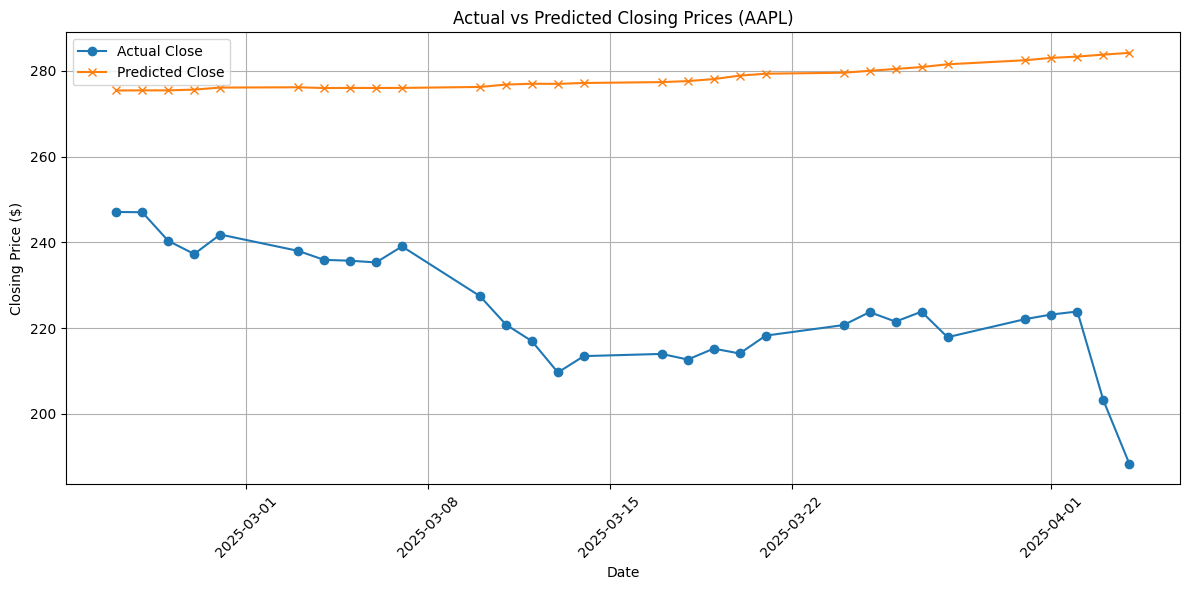

In [37]:
import matplotlib.pyplot as plt

symbol = "AAPL"
test_eval = evaluation_results[symbol]

plt.figure(figsize=(12, 6))
plt.plot(test_eval["ds"], test_eval["y"], label="Actual Close", marker='o')
plt.plot(test_eval["ds"], test_eval["Predicted_Close"], label="Predicted Close", marker='x')

plt.title(f"Actual vs Predicted Closing Prices ({symbol})")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔹 Step 8: Calculate Error Metrics

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

for symbol in symbols:
    test_eval = evaluation_results[symbol]
    mae = mean_absolute_error(test_eval["y"], test_eval["Predicted_Close"])
    rmse = np.sqrt(mean_squared_error(test_eval["y"], test_eval["Predicted_Close"]))

    print(f"📉 {symbol} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")


📉 AAPL - MAE: 54.14, RMSE: 56.22
📉 MSFT - MAE: 60.56, RMSE: 61.19
📉 GOOGL - MAE: 48.86, RMSE: 49.50
📉 AMZN - MAE: 54.89, RMSE: 55.78
📉 TSLA - MAE: 140.86, RMSE: 142.98


🔹 Step 9: Save Forecast to JSON or CSV

In [ ]:
for symbol in symbols:
    forecast = forecast_outputs[symbol]

    # Rename columns before saving
    forecast = forecast.rename(columns={
        "yhat": "Predicted_Close",
        "yhat_upper": "Upper_Bound",
        "yhat_lower": "Lower_Bound"
    })

    forecast[["ds", "Predicted_Close", "Upper_Bound", "Lower_Bound"]].to_csv(
        f"data/stock/prophet/{symbol}_forecast.csv", index=False
    )

    forecast[["ds", "Predicted_Close", "Upper_Bound", "Lower_Bound"]].tail(30).to_json(
        f"data/stock/prophet/{symbol}_next_30_days.json", orient="records"
    )


🔹 Step 10: Calculate Growth & Volatility and Save for Gemini


In [ ]:
# Step 10: Calculate Growth & Volatility for Chatbot (Gemini)

growth_volatility_stats = {}

for symbol in symbols:
    forecast = forecast_outputs[symbol]

    # Rename before accessing values
    forecast = forecast.rename(columns={
        "yhat": "Predicted_Close",
        "yhat_upper": "Upper_Bound",
        "yhat_lower": "Lower_Bound"
    })

    #  Use only last 30 days for calculation
    recent = forecast.tail(30)

    start_price = recent["Predicted_Close"].iloc[0]
    end_price = recent["Predicted_Close"].iloc[-1]
    growth = ((end_price - start_price) / start_price) * 100
    volatility = recent["Predicted_Close"].std()

    growth_volatility_stats[symbol] = {
        "start_price": round(start_price, 2),
        "end_price": round(end_price, 2),
        "growth": round(growth, 2),
        "volatility": round(volatility, 2)
    }

#  Save to JSON for chatbot use
with open("data/stock/prophet/forecast_summary.json", "w") as f:
    import json
    json.dump(growth_volatility_stats, f, indent=2)

print("✅ Forecast summary saved to forecast_summary.json")


✅ Forecast summary saved to forecast_summary.json


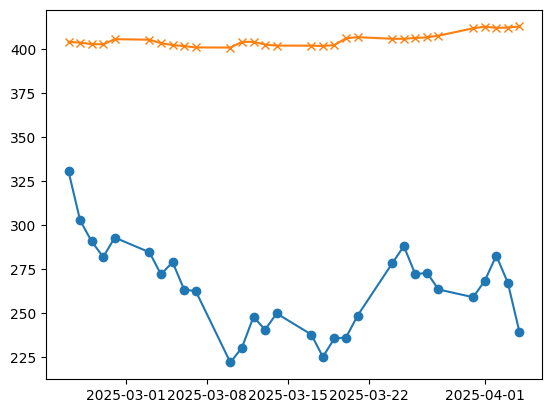

In [34]:
plt.plot(test_eval["ds"], test_eval["y"], label="Actual Close", marker='o')
plt.plot(test_eval["ds"], test_eval["Predicted_Close"], label="Predicted Close", marker='x')
